# measure

> This notebook provides utilities used in measuring the ICL in images of galaxy clusters.

In [ ]:
# | default_exp measure

In [ ]:
# | export
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.stats import SigmaClip
from astropy.table import QTable
from matplotlib import patches
from photutils.aperture import ApertureStats, EllipticalAnnulus, EllipticalAperture
from photutils.isophote import (
    Ellipse,
    EllipseGeometry,
    EllipseSample,
    Isophote,
    IsophoteList,
)
from sigfig import round

from nicl.utilities import (
    get_cutout,
    get_img_centre_pixel,
    get_pixel_scale,
    pix2arcmin,
    pix2Mpc,
)

In [ ]:
# | hide
# Additional imports used in the examples
from astropy.convolution import Gaussian2DKernel
from numpy.testing import assert_almost_equal
from photutils.aperture import RectangularAperture
from photutils.isophote import build_ellipse_model

## Measuring the ICL shape

To estimate the ellipticity and position angle of the ICL we measure the eigenvectors and eigenvalues of the ICL. This method does a reasonable job, but may be influenced by significant masking, noise and unsubtracted background features.

First we need to define some mathematical functions.

In [ ]:
# | export


def eigh_w(
    X: np.ndarray,  # an n x m covariance matrix
    w: np.ndarray,  # an array of m weights
) -> tuple[np.ndarray, np.ndarray]:  # the eigenvalues and eigenvectors
    """Return eigenvalues and vectors of the weighted covariance matrix of X."""
    w_sum = np.sum(w)
    covmat = np.dot(X.T * w, X) / (w_sum - np.sum(w**2) / w_sum)
    val, vec = np.linalg.eigh(covmat)
    return val[::-1], vec[::-1]


def eigenvec(
    X: np.ndarray,  # an n x m covariance matrix
    w: np.ndarray | None = None,  # an array of m weights
    recentre=True,  # should the data be recentred
    method=eigh_w,  # the function to use to calculate the eigenvectors
) -> tuple[
    np.ndarray, np.ndarray, np.ndarray
]:  # the mean, eigenvalues and eigenvectors
    """Compute mean, eigenvalues and vectors of the covariance matrix of X.

    Optional weighting and centering.

    The method for calculating eigenvalues and vectors can be changed.
    """
    if w is None:
        w = np.ones(len(X))
    if recentre:
        mean = np.sum(X.T * w, axis=1) / w.sum()
    else:
        mean = np.zeros(X.shape[1])
    m = X - mean
    val, vec = method(m, w)
    return mean, val, vec

Then we can define the function to compute the ellipse.

In [ ]:
# | export


def get_eigen_ellipse(
    data: np.ndarray,  # the input data
    mask: np.ndarray | None = None,  # an optional mask
    recentre=True,  # should the data be recentred
    method=eigh_w,  # the function to use to calculate the eigenvectors
) -> tuple[np.ndarray, float, float, float]:  # the ellipse parameters
    """Compute the eigenvector ellipse from `data`.

    The returned parameters are:

    * `centre`: the x, y offsets from the centre of the input `data` array,
    * `semimajoraxis`: the 'standard deviation' of the data along the major axis,
    * `axis_ratio`: the minor-to-major axis ratio,
    * `position_angle`: the position angle of the major axis in degrees.
    """
    indices = np.indices(data.shape).T
    centre = get_img_centre_pixel(data)
    offsets = indices - centre
    if mask is None:
        mask = np.zeros(data.shape, bool).T
    else:
        # ensure boolean as affects how numpy uses it
        mask = mask.astype(bool).T
    offsets = offsets[~mask]
    weights = data.T[~mask]
    weights /= weights.sum()
    centre, val, vec = eigenvec(offsets, weights, recentre, method)
    # standardize vector to point to +ve delta RA
    if vec[0, 0] < 0:
        vec *= -1
    semimajoraxis, semiminoraxis = np.sqrt(val)
    axis_ratio = semiminoraxis / semimajoraxis
    position_angle = np.degrees(np.arctan2(*vec[0]))
    return centre, semimajoraxis, axis_ratio, position_angle

This function creates a matplotlib patch that can be added to an image.

In [ ]:
# | export


def ellipse_patch(
    image: np.ndarray,  # the image the patch will be plotted on
    centre: np.ndarray,  # the x, y offsets from the centre of `image`%%!
    semimajoraxis: float,  # the semimajor axis length
    axis_ratio: float,  # the minor-to-major axis ratio
    position_angle: float,  # the position angle of the major axis in degrees
) -> patches.Ellipse:  # a matplotlib patch
    """Create an ellipse patch for plotting."""
    return patches.Ellipse(
        (get_img_centre_pixel(image) + centre)[::-1],
        2 * semimajoraxis * axis_ratio,
        2 * semimajoraxis,
        angle=90 + position_angle,
        fc="none",
        ec="w",
    )

Now let's check this works. Create a Gaussian with known parameters and check we recover them to reasonable accuracy.

In [ ]:
test_img = Gaussian2DKernel(
    x_stddev=10.0, y_stddev=20.0, x_size=150, y_size=140, theta=-30 * np.pi / 180
).array
test_img = test_img[:130]
centre, semimajoraxis, axis_ratio, position_angle = get_eigen_ellipse(test_img)
print(centre, semimajoraxis, axis_ratio, position_angle)
assert_almost_equal(centre, (5, 0), decimal=1)
assert_almost_equal(semimajoraxis, 20.0, decimal=1)
assert_almost_equal(axis_ratio, 0.5, decimal=1)
assert_almost_equal(position_angle, 90 - 30, decimal=1)

[ 4.97556232 -0.00976776] 19.94811074743355 0.5012829780149983 59.93803639531848


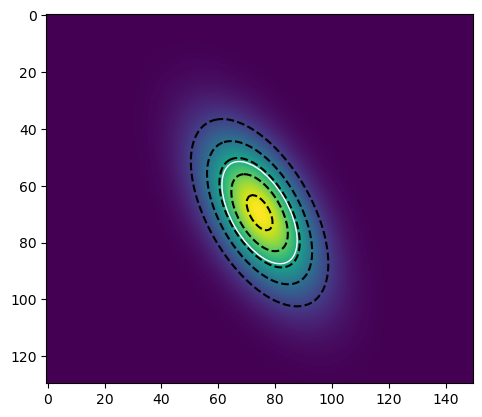

In [ ]:
fig, ax = plt.subplots()
ax.imshow(test_img)
ax.contour(test_img, levels=5, colors="k", linestyles="--")
ellipse = ellipse_patch(test_img, centre, semimajoraxis, axis_ratio, position_angle)
ax.add_patch(ellipse);

In [ ]:
# |export


def estimate_icl_shape(image, mask, r500_angular, bcg_pos=None, allow_icl_offset=False):
    cutout, mask = get_cutout(image, 0.8 * r500_angular, bcg_pos, mask=mask)
    centre, semimajoraxis, ax_ratio, pa = get_eigen_ellipse(
        cutout, mask, allow_icl_offset
    )
    return pa, ax_ratio, centre, semimajoraxis

For future reference, note that the above could also be acheived with `photutils`, except that the centroid cannot be held fixed:

In [ ]:
ap = RectangularAperture(get_img_centre_pixel(test_img), *test_img.shape)
s = ApertureStats(test_img, ap)
print(1 - s.ellipticity, 90 * u.deg - s.orientation, s.centroid)

0.501285099257609 30.057019375560778 deg [74.489429   69.47501713]


## Measuring the profile with concentric elliptical annuli

In [ ]:
# | exports


def add_surface_brightness(profile, avg, pixel_size, zp):
    sb_zp = (2.5 * np.log10(pixel_size.to_value(u.arcsec / u.pix) ** 2)) + zp.to_value(
        u.ABmag
    )
    profile = profile.copy()
    profile[f"{avg}_snr"] = profile[avg] / profile[f"{avg}_err"]
    profile[f"{avg}_sb_err"] = 2.5 / (profile[f"{avg}_snr"] * np.log(10))
    # ignore log10 of negative number RuntimeWarning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        profile[f"{avg}_sb"] = -2.5 * np.log10(profile[avg]) + sb_zp
        profile[f"{avg}_sb_err_bright"] = (
            -2.5 * np.log10(profile[avg] + profile[f"{avg}_err"]) + sb_zp
        )
        profile[f"{avg}_sb_err_faint"] = (
            -2.5 * np.log10(profile[avg] - profile[f"{avg}_err"]) + sb_zp
        )
    return profile


def calculate_icl_profile(
    image,
    mask,
    r500_angular,
    zp=27 * u.ABmag,
    annulus_width_pix=5.0,
    bcg_pos=None,
    allow_icl_offset=False,
    sigma_clip=True,
    n_sigma=3.0,
):
    pa, ax_ratio, centre, semimajoraxis = estimate_icl_shape(
        image, mask, r500_angular, bcg_pos, allow_icl_offset
    )
    pixel_size = get_pixel_scale(image) / u.pix
    r500_pix = (r500_angular / pixel_size).to_value(u.pix)
    icl_shape = (centre, r500_pix, ax_ratio, pa)

    a500_pix = r500_pix / np.sqrt(ax_ratio)
    outer_semimajor = np.arange(
        annulus_width_pix * 2, 1.25 * a500_pix + annulus_width_pix, annulus_width_pix
    )

    if bcg_pos is None:
        bcg_pos = get_img_centre_pixel(image).astype(int)
    centre = bcg_pos + centre

    apertures = [
        EllipticalAnnulus(
            positions=centre,
            a_in=a_out - annulus_width_pix,
            a_out=a_out,
            b_out=a_out * ax_ratio,
            theta=pa,
        )
        for a_out in outer_semimajor
    ]

    profile = QTable()
    # Mean profile, using sigma clipping by default
    if sigma_clip:
        sig_clip = SigmaClip(sigma=n_sigma, cenfunc="mean", maxiters=5)
    else:
        sig_clip = None
    aperture_stats = [
        ApertureStats(image.data, ap, mask=mask, sigma_clip=sig_clip)
        for ap in apertures
    ]
    profile["mean"] = [ap.mean for ap in aperture_stats]
    profile["mean_std"] = [ap.std for ap in aperture_stats]
    profile["mean_area"] = [ap.sum_aper_area / u.pix**2 for ap in aperture_stats]
    profile["mean_err"] = profile["mean_std"] / np.sqrt(profile["mean_area"])
    profile = add_surface_brightness(profile, "mean", pixel_size, zp)
    # Median profile, without sigma clipping
    aperture_stats = [ApertureStats(image.data, ap, mask=mask) for ap in apertures]
    profile["median"] = [ap.median for ap in aperture_stats]
    profile["median_std"] = [ap.mad_std for ap in aperture_stats]
    profile["median_area"] = [ap.sum_aper_area / u.pix**2 for ap in aperture_stats]
    profile["median_err"] = profile["median_std"] / np.sqrt(profile["median_area"])
    profile = add_surface_brightness(profile, "median", pixel_size, zp)
    # Aperture properties
    profile["aperture"] = apertures
    profile["total_area"] = [ap.area for ap in apertures]
    profile["semimajoraxis"] = outer_semimajor - annulus_width_pix / 2
    profile["semimajoraxis_r500"] = profile["semimajoraxis"] / r500_pix
    profile["radius"] = profile["semimajoraxis"] * np.sqrt(ax_ratio)
    profile["radius_r500"] = profile["radius"] / r500_pix
    return profile, icl_shape


def icl_total_flux(flux, error, area):
    sum = np.nansum(flux * area)
    err = np.sqrt(np.nansum((error * area) ** 2))
    return sum, err


def background_correct_profile(background_profile, profile, image, zp):
    profile = profile.copy()
    pixel_size = get_pixel_scale(image) / u.pix
    sb_zp = zp.to_value(u.ABmag) + (
        2.5 * np.log10(pixel_size.to_value(u.arcsec / u.pix) ** 2)
    )
    bkg = {}
    for avg in ("mean", "median"):
        bkg[avg] = background_profile[avg].mean()
        bkg[f"{avg}_err"] = background_profile[avg].std()
        print("background for {} is {}".format(avg, round(bkg[avg], bkg[f"{avg}_err"])))
        profile[avg] -= bkg[avg]
        profile[f"{avg}_err"] = np.sqrt(
            profile[f"{avg}_err"] ** 2 + bkg[f"{avg}_err"] ** 2
        )
        profile = add_surface_brightness(profile, avg, pixel_size, zp)
        bkg[f"{avg}_sb_err"] = -2.5 * np.log10(bkg[f"{avg}_err"]) + sb_zp
    return bkg, profile

## Fitting elliptial isophotes

In [ ]:
# | exports


def calculate_icl_isophotes(
    image,
    full_mask,
    bcg_mask,
    r500_angular,
    zp=27 * u.ABmag,
    bcg_pos=None,
    allow_icl_offset=False,
    sigma_clip=True,
    n_sigma=3.0,
    fix_pa=False,
    fix_eps=False,
):
    pa, ax_ratio, centre, semimajoraxis = estimate_icl_shape(
        image, full_mask, r500_angular, bcg_pos, allow_icl_offset
    )

    pixel_size = get_pixel_scale(image) / u.pix
    r500_pixel = r500_angular / pixel_size

    if bcg_pos is None:
        bcg_pos = get_img_centre_pixel(image)
    centre = bcg_pos + centre
    geometry = EllipseGeometry(
        x0=centre[1],
        y0=centre[0],
        sma=semimajoraxis,
        eps=1 - ax_ratio,
        pa=pa * np.pi / 180.0,
    )
    obj_mask = full_mask ^ bcg_mask
    masked_image = np.where(obj_mask, np.nan, image.data)
    masked_image = np.ma.masked_where(obj_mask, masked_image)
    ellipse = Ellipse(masked_image, geometry)
    isolist = ellipse.fit_image(
        sma0=0.1 * r500_pixel.to_value(u.pix),
        maxsma=1.25 * r500_pixel.to_value(u.pix),
        maxrit=0.5 * r500_pixel.to_value(u.pix),
        sclip=n_sigma,
        nclip=5 if sigma_clip else 0,
        fflag=0.1,
        integrmode="median",
        fix_center=not allow_icl_offset,
        fix_pa=fix_pa,
        fix_eps=fix_eps,
    )
    # Now remeasure the annular photometry using the same isophotes with the BCG masked
    bcg_masked_image = np.where(full_mask, np.nan, image.data)
    bcg_masked_image = np.ma.masked_where(full_mask, bcg_masked_image)
    bcg_masked_isolists = {"median": [], "mean": []}
    for iso in isolist[1:]:
        g = iso.sample.geometry
        for avg in ["median", "mean"]:
            sample = EllipseSample(
                bcg_masked_image,
                g.sma,
                geometry=g,
                integrmode=avg,
                sclip=n_sigma,
                nclip=5 if sigma_clip else 0,
            )
            sample.update()
            bcg_masked_isolists[avg].append(Isophote(sample, 0, True, 0))
    for avg in ["median", "mean"]:
        bcg_masked_isolists[avg] = IsophoteList(bcg_masked_isolists[avg])
    return bcg_masked_isolists

Now let's demonstrate this on the test image.

In [ ]:
mask = np.zeros(test_img.shape, bool)
mask[40:50, 40:60] = True
test_img_masked = test_img + 0.00002 * np.random.normal(size=test_img.shape)
test_img_masked[mask] = 0
test_img_masked = np.ma.masked_where(mask, test_img_masked)

In [ ]:
centre = get_img_centre_pixel(test_img_masked)
geometry = EllipseGeometry(
    x0=centre[1], y0=centre[0], sma=30, eps=0.6, pa=50 * np.pi / 180.0
)
ellipse = Ellipse(test_img_masked, geometry)
isophotes = ellipse.fit_image(step=0.2, nclip=5)

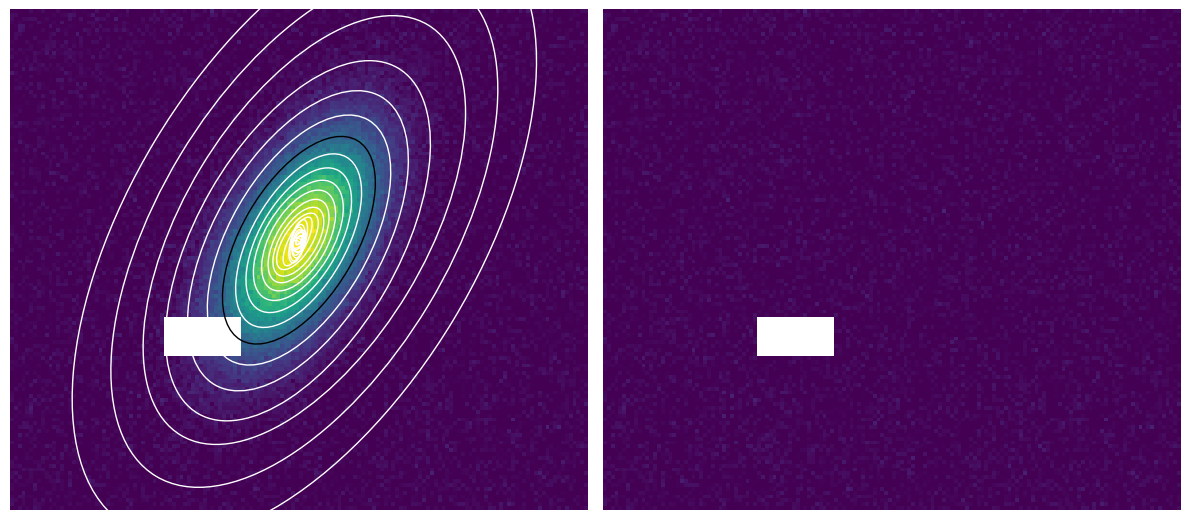

In [ ]:
model_image = build_ellipse_model(test_img_masked.shape, isophotes)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
ax[0].imshow(test_img_masked, origin="lower", vmin=0, vmax=0.0008)

for iso in isophotes:
    if iso.sma > 1:
        aper = EllipticalAperture(
            (iso.x0, iso.y0), iso.sma, iso.sma * (1 - iso.eps), iso.pa
        )
        aper.plot(ax=ax[0], color="black" if iso.sma == 30 else "white")
ax[1].imshow(test_img_masked - model_image, origin="lower", vmin=0, vmax=0.0008)

for a in ax:
    a.axis("off")
plt.tight_layout()

## Plotting ICL profiles

In [ ]:
# | export


def plot_icl_profile(
    profile,
    averages=["mean", "median"],
    surface_brightness=True,
    radius="semimajoraxis_r500",
    bkg=None,
    max_sb_err=1.0,
    ax=None,
):
    colors = dict(mean="indigo", median="orange")
    if ax is None:
        fig, ax = plt.subplots()
    averages = [averages] if not isinstance(averages, list) else averages
    ax.set_xlabel(r"$r\,/\,R_{500}$")
    if surface_brightness:
        ax.set_ylabel(r"$\mu_{i}~{\rm[mag\; arcsec^{-2}]}$")
        if bkg is not None:
            for i in [1, 2, 3]:
                bkg_line = ax.axhline(
                    bkg["mean_sb_err"] - 2.5 * np.log10(i), ls="--", color="gray"
                )
                ax.annotate(
                    f"{i}" + r"$\times$ background noise level",
                    xy=(0.01, 0.0),
                    xycoords=bkg_line,
                    ha="left",
                    va="top",
                )
        ax.set_ylim(32, 23)
    else:
        ax.set_ylabel(r"$I_{i}~{\rm[counts\; pixel^{-1}]}$")
        if bkg is not None:
            ax.axhline(3 * bkg["mean_err"], ls=":", color="gray")
            bkg_line = ax.axhline(-3 * bkg["mean_err"], ls=":", color="gray")
            ax.annotate(
                r"± 3 $\times$ background error ",
                xy=(0.01, 0.0),
                xycoords=bkg_line,
                ha="left",
                va="top",
            )
    for avg in averages:
        color = colors[avg]
        if surface_brightness:
            avg = f"{avg}_sb"
            p = profile[profile[f"{avg}_err"] <= max_sb_err]
        else:
            p = profile
        ax.plot(p[radius], p[avg], c=color)
        ax.fill_between(
            p[radius],
            p[avg] - p[f"{avg}_err"],
            p[avg] + p[f"{avg}_err"],
            color=color,
            edgecolor="none",
            alpha=0.6,
        )
    ax.set_xlim(0, 1.1)

In [ ]:
# | export


def plot_icl_image(img, icl_shape, z, norm=None, ax=None):
    isophote_colors = ["white", "orange", "orange", "yellow", "yellow", "red"]
    ax.imshow(img, origin="lower", norm=norm)
    ax.axis("off")
    sax = ax.secondary_xaxis("bottom", functions=pix2arcmin(1, img))
    sax.set_xlabel("RA offset [arcmin]")
    sax = ax.secondary_yaxis("left", functions=pix2arcmin(0, img))
    sax.set_ylabel("Dec offset [arcmin]")
    sax = ax.secondary_xaxis("top", functions=pix2Mpc(1, img, z))
    sax.set_xlabel("RA offset [Mpc]")
    sax = ax.secondary_yaxis("right", functions=pix2Mpc(0, img, z))
    sax.set_ylabel("Dec offset [Mpc]")
    if isinstance(icl_shape, IsophoteList):
        for iso in icl_shape:
            if iso.sma > 1:
                aper = EllipticalAperture(
                    (iso.x0, iso.y0), iso.sma, iso.sma * (1 - iso.eps), iso.pa
                )
                aper.plot(ax=ax, color=isophote_colors[iso.stop_code])
    else:
        centre, r500_pix, ax_ratio, pa = icl_shape
        for f in (0.2, 0.4, 0.6, 0.8, 1.0):
            ax.add_patch(ellipse_patch(img, centre, f * r500_pix, ax_ratio, pa))

In [ ]:
# | export


def plot_icl(
    img,
    profile,
    icl_shape,
    z,
    averages=["mean", "median"],
    surface_brightness=True,
    radius="semimajoraxis_r500",
    bkg=None,
    max_sb_err=1.0,
    norm=None,
):
    fig, (ax_prof, ax_img) = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
    ax_prof.set_box_aspect(1)
    plot_icl_profile(
        profile,
        averages=averages,
        surface_brightness=surface_brightness,
        radius=radius,
        bkg=bkg,
        ax=ax_prof,
    )
    plot_icl_image(img, icl_shape, z, norm=norm, ax=ax_img)

### Converting isophotes to profile for plotting

In [ ]:
# | export


def profile_from_isolists(isolists, img, r500_angular):
    pixel_size = get_pixel_scale(img) / u.pix
    r500_pixel = (r500_angular / pixel_size).to_value(u.pix)
    isoprofile = isolists["median"].to_table()
    isoprofile.rename_columns(
        ["sma", "intens", "intens_err"], ["semimajoraxis", "median", "median_err"]
    )
    isoprofile["semimajoraxis_r500"] = isoprofile["semimajoraxis"] / r500_pixel
    isoprofile["semimajoraxis_r500"] = isoprofile["semimajoraxis"] / r500_pixel
    isoprofile["radius"] = isoprofile["semimajoraxis"] * np.sqrt(
        1 - isoprofile["ellipticity"]
    )
    isoprofile["radius_r500"] = isoprofile["radius"] / r500_pixel
    isoprofile["mean"] = isolists["mean"].intens
    isoprofile["mean_err"] = isolists["mean"].int_err
    return isoprofile

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()